# P-Q decrement analysis of the Harlequin free decay tests

Converts the measured decrement coefficients $P$ and $Q$ into linear and quadratic damping (Journée & Massie):

$$b_L = 2\,P\,\frac{m+a}{T_n}, \qquad b_q = \frac{3}{8}\,Q\,(m+a)$$

The effective mass/inertia is taken per test from the hydrostatic stiffness,

$$M_\mathrm{eff} = K\left(\frac{T_n}{2\pi}\right)^2,$$

so the **experimental** natural period is used and the aerodynamic added-mass correction is automatically included.

$b_L$ here is the **total** linear damping in the signal (radiation included), so it is comparable to the radiation-inclusive calibration plot, not the viscous-only one. Stiffness is in SI / radians: heave in kN/m, pitch and roll in kN·m/rad.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Hydrostatic stiffness

`no_deck` uses the `fixed` hull stiffness: removing the deck changes neither the waterplane nor the displacement, so $K$ is unchanged. Only the mass differs and that enters through the experimental $T_n$.

In [3]:
K = {
    "spring":  {"heave": 211.789, "pitch": 7932.67, "roll": 7932.65},
    "fixed":   {"heave": 211.789, "pitch": 8508.24, "roll": 8508.22},
    "no_deck": {"heave": 211.789, "pitch": 8508.24, "roll": 8508.22},
}

## MARIN P-Q results

Rows: `(config, DOF, T_n [s], P [-], Q [1/motion])`, transcribed from the MARIN decrement table (test series 34224_03CB).

In [4]:
rows = [
    # spring with deck
    ("spring", "pitch", 7.24, 0.054, 0.024),
    ("spring", "pitch", 7.24, 0.056, 0.026),
    ("spring", "pitch", 7.24, 0.041, 0.028),
    ("spring", "pitch", 7.26, 0.088, 0.017),
    ("spring", "roll",  7.18, 0.096, 0.009),
    ("spring", "roll",  7.18, 0.052, 0.022),
    ("spring", "roll",  7.17, 0.037, 0.026),
    ("spring", "roll",  7.17, 0.071, 0.021),
    ("spring", "roll",  7.15, 0.020, 0.033),
    ("spring", "heave", 4.15, 0.116, 0.104),
    ("spring", "heave", 4.14, 0.089, 0.148),
    ("spring", "heave", 4.15, 0.104, 0.134),
    ("spring", "heave", 4.14, 0.160, 0.111),
    # fixed with deck
    ("fixed", "pitch", 6.56, 0.035, 0.033),
    ("fixed", "pitch", 6.56, 0.021, 0.035),
    ("fixed", "pitch", 6.55, 0.000, 0.034),
    ("fixed", "roll",  6.57, 0.026, 0.031),
    ("fixed", "roll",  6.56, 0.041, 0.041),
    ("fixed", "roll",  6.54, 0.000, 0.045),
    ("fixed", "heave", 4.01, 0.132, 0.130),
    ("fixed", "heave", 4.00, 0.038, 0.227),
    ("fixed", "heave", 4.03, 0.175, 0.124),
    ("fixed", "heave", 3.99, 0.151, 0.153),
    ("fixed", "heave", 4.03, 0.064, 0.181),
    # fixed no deck
    ("no_deck", "pitch", 6.23, 0.000, 0.033),
    ("no_deck", "pitch", 6.23, 0.000, 0.034),
    ("no_deck", "pitch", 6.23, 0.000, 0.034),
    ("no_deck", "pitch", 6.25, 0.000, 0.032),
    ("no_deck", "roll",  6.31, 0.000, 0.024),
    ("no_deck", "roll",  6.23, 0.049, 0.016),
    ("no_deck", "roll",  6.24, 0.000, 0.034),
    ("no_deck", "roll",  6.25, 0.106, -0.010),
    ("no_deck", "heave", 3.81, 0.151, 0.016),
    ("no_deck", "heave", 3.82, 0.050, 0.112),
    ("no_deck", "heave", 3.83, 0.056, 0.125),
    ("no_deck", "heave", 3.82, 0.073, 0.078),
]

df = pd.DataFrame(rows, columns=["config", "dof", "Tn", "P", "Q"])

## Convert to damping coefficients

`P` is a (dimensionless) logarithmic decrement, so `b_L` is unaffected by the
angle unit. `Q` is reported in **1/deg** for the rotational DOFs, whereas the
OrcaFlex EOM uses rad/s, so the pitch/roll quadratic coefficient is converted
with $q_\mathrm{rad}=\tfrac{180}{\pi}q_\mathrm{deg}$. Heave is translational
(motion in m) and needs no conversion.

In [5]:
DEG2RAD = 180 / np.pi   # q_rad = (180/pi) * q_deg

df["K"]     = df.apply(lambda r: K[r.config][r.dof], axis=1)
df["M_eff"] = df["K"] * (df["Tn"] / (2 * np.pi))**2
df["b_L"]   = 2 * df["P"] * df["M_eff"] / df["Tn"]
df["b_q"]   = (3/8) * df["Q"] * df["M_eff"]

# Q is in 1/deg for the angular DOFs -> convert b_q to rad-based units
ang = df["dof"].isin(["pitch", "roll"])
df.loc[ang, "b_q"] *= DEG2RAD

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
df

,config,dof,Tn,P,Q,K,M_eff,b_L,b_q
0,spring,pitch,7.240,0.054,0.024,"7,932.670","10,532.629",157.117,"5,431.277"
1,spring,pitch,7.240,0.056,0.026,"7,932.670","10,532.629",162.936,"5,883.883"
2,spring,pitch,7.240,0.041,0.028,"7,932.670","10,532.629",119.292,"6,336.489"
3,spring,pitch,7.260,0.088,0.017,"7,932.670","10,590.901",256.749,"3,868.439"
4,spring,roll,7.180,0.096,0.009,"7,932.650","10,358.752",277.003,"2,003.106"
5,spring,roll,7.180,0.052,0.022,"7,932.650","10,358.752",150.043,"4,896.480"
6,spring,roll,7.170,0.037,0.026,"7,932.650","10,329.918",106.613,"5,770.642"
7,spring,roll,7.170,0.071,0.021,"7,932.650","10,329.918",204.581,"4,660.903"
8,spring,roll,7.150,0.020,0.033,"7,932.650","10,272.370",57.468,"7,283.472"
9,spring,heave,4.150,0.116,0.104,211.789,92.393,5.165,3.603


## Calibrated OrcaFlex damping values

Load the per-test damping values calibrated in OrcaFlex. The **total** columns
(viscous + radiation) are used so they are directly comparable to the P-Q
$b_L$, which also contains radiation. The construction names are mapped to the
same keys used above.

In [6]:
EXCEL_PATH = "damping_summary_all_dofs.xlsx"   # adjust if needed

cal = pd.read_excel(EXCEL_PATH, sheet_name="individual_results_all_dofs")
cal = cal.rename(columns={"construction": "config",
                          "total_linear_damping": "b_L",
                          "total_quadratic_damping": "b_q"})
cal["config"] = cal["config"].map({"spring": "spring",
                                    "fixedwith": "fixed",
                                    "fixedwithout": "no_deck"})
cal = cal[["config", "dof", "b_L", "b_q"]]
cal.head()

,config,dof,b_L,b_q
0,spring,heave,6.730,2.000
1,spring,heave,5.230,3.750
2,spring,heave,5.730,3.500
3,spring,heave,9.480,1.750
4,fixed,heave,8.550,0.500


## Scatter per DOF — P-Q vs calibrated

Crosses ($\times$) are the P-Q decrement estimates; filled circles ($\bullet$)
are the OrcaFlex-calibrated values. Colour denotes configuration. Both axes
start at zero. The single `fixed without deck` roll P-Q point with $Q=-0.010$
gives a non-physical negative $b_q\approx-32$ and falls below the visible range
— itself a symptom of the ill-conditioned linear/quadratic split for the
lightly damped tests.

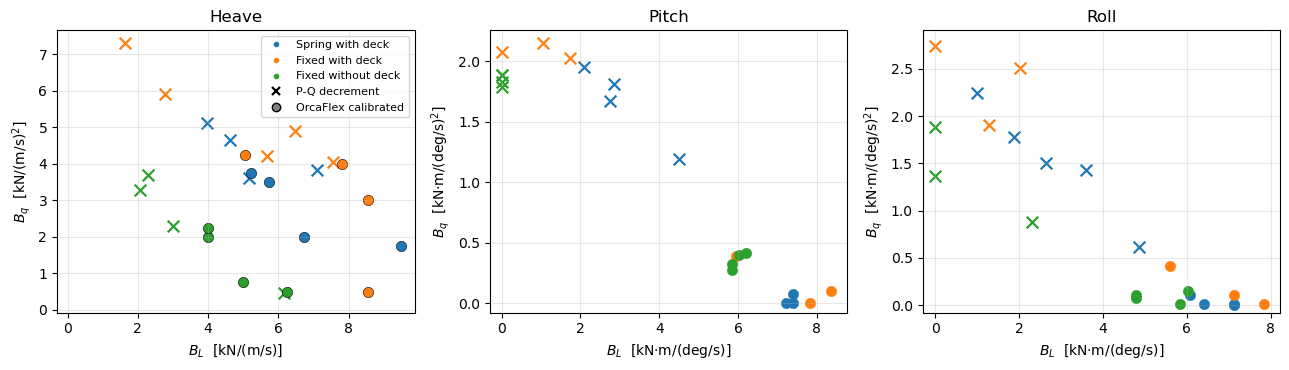

In [9]:
from matplotlib.lines import Line2D

colors = {"spring": "#1f77b4", "fixed": "#ff7f0e", "no_deck": "#2ca02c"}
labels = {"spring": "Spring with deck",
          "fixed":  "Fixed with deck",
          "no_deck": "Fixed without deck"}

units = {"heave": ("kN/(m/s)", "kN/(m/s)$^2$"),
         "pitch": ("kN·m/(deg/s)", "kN·m/(deg/s)$^2$"),
         "roll":  ("kN·m/(deg/s)", "kN·m/(deg/s)$^2$")}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, dof in zip(axes, ["heave", "pitch", "roll"]):
    for cfg in ["spring", "fixed", "no_deck"]:
        c = colors[cfg]
        pq = df[(df.dof == dof) & (df.config == cfg)]
        if dof in ["pitch", "roll"]:
            ax.scatter(pq.b_L/57, pq.b_q/57**2, marker="x", c=c, s=70, linewidth=1.6)
            cl = cal[(cal.dof == dof) & (cal.config == cfg)]
            ax.scatter(cl.b_L/57, cl.b_q/57**2, marker="o", facecolor=c,
                   edgecolor=c, linewidth=0.4, s=55)
        else:
            ax.scatter(pq.b_L, pq.b_q, marker="x", c=c, s=70, linewidth=1.6)
            cl = cal[(cal.dof == dof) & (cal.config == cfg)]
            ax.scatter(cl.b_L, cl.b_q, marker="o", facecolor=c,
                   edgecolor="k", linewidth=0.4, s=55)
    ax.set_title(dof.capitalize())
    ax.set_xlabel(f"$B_L$  [{units[dof][0]}]")
    ax.set_ylabel(f"$B_q$  [{units[dof][1]}]")
    ax.set_xlim(left=-0.3)
    ax.set_ylim(bottom=-0.08)
    ax.grid(alpha=0.3)

config_handles = [Line2D([0], [0], marker=".", linestyle="", markerfacecolor=colors[c],
                         markeredgecolor=colors[c], markersize=6, label=labels[c])
                  for c in ["spring", "fixed", "no_deck"]]
method_handles = [Line2D([0], [0], marker="x", linestyle="", color="k",
                         markersize=6, markeredgewidth=1.6, label="P-Q decrement"),
                  Line2D([0], [0], marker="o", linestyle="", markerfacecolor="grey",
                         markeredgecolor="k", markersize=6, label="OrcaFlex calibrated")]
axes[0].legend(handles=config_handles + method_handles, fontsize=8, loc="best")

# fig.suptitle("Linear vs quadratic damping: P-Q decrement estimate vs OrcaFlex "
            #  "calibration (total, radiation included)")
fig.tight_layout()
plt.show()

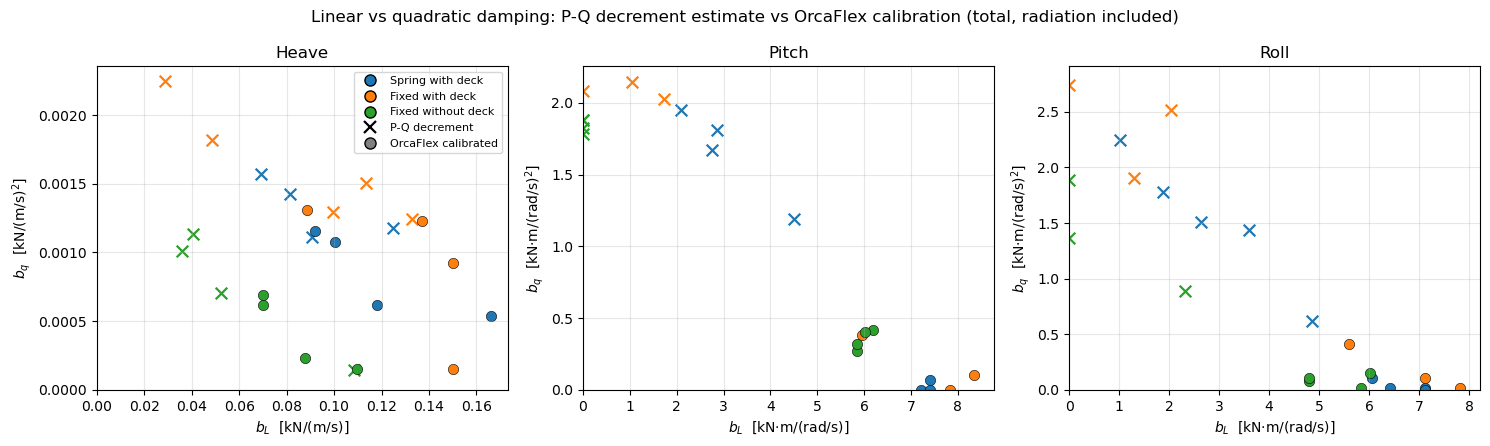

In [8]:
from matplotlib.lines import Line2D

colors = {"spring": "#1f77b4", "fixed": "#ff7f0e", "no_deck": "#2ca02c"}
labels = {"spring": "Spring with deck",
          "fixed":  "Fixed with deck",
          "no_deck": "Fixed without deck"}

units = {"heave": ("kN/(m/s)", "kN/(m/s)$^2$"),
         "pitch": ("kN·m/(rad/s)", "kN·m/(rad/s)$^2$"),
         "roll":  ("kN·m/(rad/s)", "kN·m/(rad/s)$^2$")}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, dof in zip(axes, ["heave", "pitch", "roll"]):
    for cfg in ["spring", "fixed", "no_deck"]:
        c = colors[cfg]
        pq = df[(df.dof == dof) & (df.config == cfg)]
        ax.scatter(pq.b_L/57, pq.b_q/57**2, marker="x", c=c, s=70, linewidth=1.6)
        cl = cal[(cal.dof == dof) & (cal.config == cfg)]
        ax.scatter(cl.b_L/57, cl.b_q/57**2, marker="o", facecolor=c,
                   edgecolor="k", linewidth=0.4, s=55)
    ax.set_title(dof.capitalize())
    ax.set_xlabel(f"$b_L$  [{units[dof][0]}]")
    ax.set_ylabel(f"$b_q$  [{units[dof][1]}]")
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)

config_handles = [Line2D([0], [0], marker="o", linestyle="", markerfacecolor=colors[c],
                         markeredgecolor="k", markersize=8, label=labels[c])
                  for c in ["spring", "fixed", "no_deck"]]
method_handles = [Line2D([0], [0], marker="x", linestyle="", color="k",
                         markersize=8, markeredgewidth=1.6, label="P-Q decrement"),
                  Line2D([0], [0], marker="o", linestyle="", markerfacecolor="grey",
                         markeredgecolor="k", markersize=8, label="OrcaFlex calibrated")]
axes[0].legend(handles=config_handles + method_handles, fontsize=8, loc="best")

fig.suptitle("Linear vs quadratic damping: P-Q decrement estimate vs OrcaFlex "
             "calibration (total, radiation included)")
fig.tight_layout()
plt.show()